In [5]:
import cv2

In [6]:
# Load the video
video = cv2.VideoCapture("./mountain.mp4")

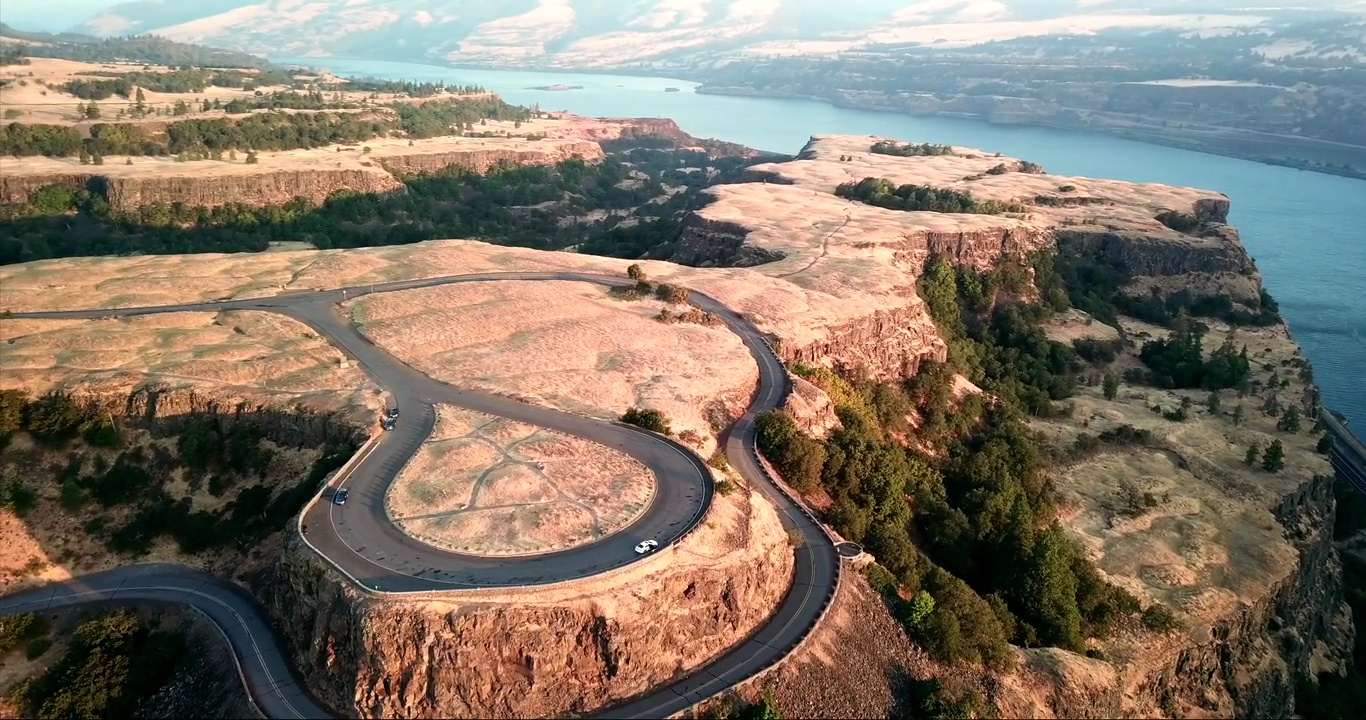

In [7]:
from IPython.display import display, Image, clear_output
import time

# Calculate delay based on actual video FPS (e.g., 30 FPS -> ~0.033s)
fps = video.get(cv2.CAP_PROP_FPS)
delay = 1.0 / fps if fps > 0 else 0.03

try:
    while video.isOpened():
        ret, frame = video.read() # if get frame then ret return true , if not frame(i.e ex. end) then ret becme false
        if not ret:
            break

        # Encode frame to JPEG format in memory
        _, buffer = cv2.imencode('.jpeg', frame)
        
        # Display the frame in the notebook output area
        clear_output(wait=True)
        display(Image(data=buffer.tobytes()))
        
        time.sleep(delay)

except KeyboardInterrupt:
    # Allows you to stop the cell cleanly using the "Stop" button in Jupyter
    pass

finally:
    video.release()

### Again macos stuck 
# # Display the video
# while True:
#     ret, frame = video.read()
#     if not ret:
#         break
#     cv2.imshow("Video Frame", frame)
#     if cv2.waitKey(1) & 0xFF == ord('q'):
#         break

# # T0 ---> f1
# # wait 1 ms
# # # T1 ---> f2

# video.release()
# cv2.destroyAllWindows()



In [ ]:
# Write a video to local storage

video = cv2.VideoCapture("./mountain.mp4")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH)) # to capture actual input video files width
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter("./output.mp4", fourcc, 30, (width, height))

while True:
    ret, frame = video.read()
    if not ret:
        break
    out.write(frame)

out.release()
video.release()
cv2.destroyAllWindows()

In [ ]:
# Write a video with updated frames

video = cv2.VideoCapture("./mountain.mp4")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter("./output_new.mp4", fourcc, 30, (width, height))

while True:
    ret, frame = video.read()
    if not ret:
        break
    frame = frame + 20 # frame change
    out.write(frame)

out.release()
video.release()
cv2.destroyAllWindows()